# Comprehensive Demo: Feature Attribution Methods with Segmentation

This notebook demonstrates all implemented feature attribution methods using the cute **buccee.jpg** image:
- Integrated Gradients
- LIME (Local Interpretable Model-agnostic Explanations)
- SHAP (SHapley Additive exPlanations)
- GradCAM (Gradient-weighted Class Activation Mapping)

**NEW**: All methods now include a `segments` field that provides segmentation information for downstream analysis.

We'll test each method on:
- ResNet50 (Computer Vision) - using buccee.jpg
- Vision Transformer (Computer Vision) - using buccee.jpg
- GPT-2 (Natural Language Processing)

In [1]:
# Setup paths and imports
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.join(os.path.abspath('..'), 'src'))

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Import all explainers
from src.exlib.new_explainers import (
    IntGradImage, IntGradText, IntGradExplanation,
    LimeImage, LimeText, LimeExplanation,
    ShapImage, ShapText, ShapExplanation,
    GradCAMImage, GradCAMText, GradCAMExplanation
)

# Import segmentation and attribution utilities
from src.exlib.new_explainers.utils.masking import patch_segment_image
from src.exlib.new_explainers.utils.attribution_utils import (
    aggregate_attributions_by_segments,
    get_top_segments,
    compare_segment_attributions
)

# Import test utilities
from tests.fixtures import (
    get_vision_model, get_text_model,
    get_test_image, get_test_text_inputs
)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("All imports successful!")

All imports successful!


In [2]:
def visualize_image_attribution(image, attribution, title="Attribution", cmap='RdBu_r'):
    """Visualize image attribution heatmap."""
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    img_display = image.permute(1, 2, 0).detach().cpu().numpy()
    img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())
    ax1.imshow(img_display)
    ax1.set_title("Buccee")
    ax1.axis('off')
    
    # Attribution heatmap (average across channels)
    attr_avg = attribution.mean(dim=0).detach().cpu().numpy()
    im = ax2.imshow(attr_avg, cmap=cmap)
    ax2.set_title(f"{title} Heatmap")
    ax2.axis('off')
    plt.colorbar(im, ax=ax2, fraction=0.046)
    
    # Overlay
    ax3.imshow(img_display)
    ax3.imshow(attr_avg, cmap=cmap, alpha=0.5)
    ax3.set_title("Overlay")
    ax3.axis('off')
    
    plt.tight_layout()
    plt.show()

def visualize_text_attribution(tokens, attribution, title="Attribution"):
    """Visualize text attribution as bar chart."""
    # Convert to numpy
    attr_values = attribution.detach().cpu().numpy()
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Create bar chart
    x = np.arange(len(tokens))
    colors = ['red' if v < 0 else 'green' for v in attr_values]
    bars = ax.bar(x, attr_values, color=colors, alpha=0.7)
    
    # Customize
    ax.set_xticks(x)
    ax.set_xticklabels(tokens, rotation=45, ha='right')
    ax.set_xlabel('Tokens')
    ax.set_ylabel('Attribution Score')
    ax.set_title(f'{title} - Token Importance')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()

print("Visualization functions defined!")

Visualization functions defined!


In [3]:
def visualize_segments(segments, title="Segmentation"):
    """Visualize segmentation map."""
    # Get 2D segments (first channel if multi-channel)
    if segments.dim() > 2:
        seg_2d = segments[0]
    else:
        seg_2d = segments
    
    plt.figure(figsize=(8, 8))
    plt.imshow(seg_2d.detach().cpu().numpy(), cmap='tab20')
    plt.title(title)
    plt.colorbar(label='Segment ID')
    plt.axis('off')
    plt.show()

def visualize_segment_attributions(attributions, segments, title="Segment Attributions"):
    """Visualize segment-level attributions."""
    from src.exlib.new_explainers.utils.attribution_utils import (
        aggregate_attributions_by_segments, 
        create_segmented_attribution_map
    )
    
    # Aggregate attributions by segments
    seg_attrs = aggregate_attributions_by_segments(attributions, segments, aggregation="mean")
    
    # Create segmented attribution map
    seg_attr_map = create_segmented_attribution_map(segments, seg_attrs)
    
    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Segment map
    seg_2d = segments[0] if segments.dim() > 2 else segments
    ax1.imshow(seg_2d.cpu().numpy(), cmap='tab20')
    ax1.set_title("Segments")
    ax1.axis('off')
    
    # Segment attributions
    seg_map_2d = seg_attr_map[0] if seg_attr_map.dim() > 2 else seg_attr_map
    im = ax2.imshow(seg_map_2d.detach().cpu().numpy(), cmap='RdBu_r')
    ax2.set_title(f"{title}")
    ax2.axis('off')
    plt.colorbar(im, ax=ax2, fraction=0.046)
    
    plt.tight_layout()
    plt.show()
    
    # Print top segments
    top_segs = get_top_segments(attributions, segments, k=5)
    print(f"Top 5 segments by importance: {top_segs.tolist()}")
    print(f"Their attribution values: {[seg_attrs[i].item() for i in top_segs]}")

print("Segment visualization functions defined!")

Segment visualization functions defined!


## Load Models

In [4]:
# Load vision models
print("Loading ResNet50...")
resnet_model, resnet_config = get_vision_model("resnet50")
resnet_model = resnet_model.to(device)
print(f"ResNet50 loaded! Input size: {resnet_config['input_size']}")

print("\nLoading Vision Transformer...")
vit_model, vit_config = get_vision_model("vit")
vit_model = vit_model.to(device)
print(f"ViT loaded! Input size: {vit_config['input_size']}")

# Load text model
print("\nLoading GPT-2...")
gpt2_model, gpt2_config = get_text_model("gpt2")
gpt2_model = gpt2_model.to(device)
tokenizer = gpt2_config["tokenizer"]
print("GPT-2 loaded!")

Loading ResNet50...
ResNet50 loaded! Input size: (224, 224)

Loading Vision Transformer...
ViT loaded! Input size: (224, 224)

Loading GPT-2...
GPT-2 loaded!


## Prepare Test Inputs

Original buccee image size: (1152, 1437)


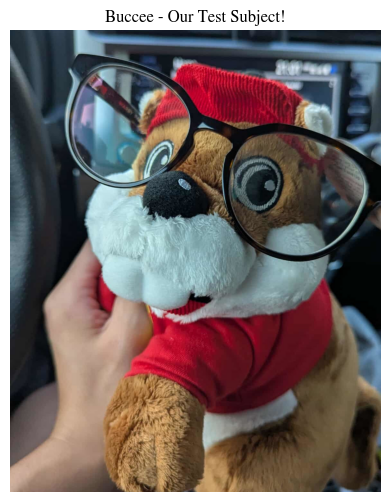


ResNet image shape: torch.Size([3, 224, 224])
ViT image shape: torch.Size([3, 224, 224])
Text tokens (13): ['The', 'Ġmovie', 'Ġwas', 'Ġabsolutely', 'Ġfantastic', ',', 'Ġwith', 'Ġgreat', 'Ġacting', 'Ġand', 'Ġstunning', 'Ġvisuals', '.']


In [5]:
# Load the cute buccee image
from PIL import Image
import torchvision.transforms as transforms

# Load buccee.jpg
buccee_path = "buccee.jpg"
buccee_pil = Image.open(buccee_path).convert('RGB')
print(f"Original buccee image size: {buccee_pil.size}")

# Create transforms for different model input sizes
transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Get test images by transforming buccee
resnet_image = transform_224(buccee_pil).to(device)
vit_image = transform_224(buccee_pil).to(device)

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(buccee_pil)
plt.title("Buccee - Our Test Subject!")
plt.axis('off')
plt.show()

# Get test text (keeping the same)
test_text = "The movie was absolutely fantastic, with great acting and stunning visuals."
inputs = tokenizer(test_text, return_tensors="pt", padding=True, truncation=True)
input_ids = inputs["input_ids"][0].to(device)
tokens = tokenizer.convert_ids_to_tokens(input_ids)

print(f"\nResNet image shape: {resnet_image.shape}")
print(f"ViT image shape: {vit_image.shape}")
print(f"Text tokens ({len(tokens)}): {tokens}")

## 1. Integrated Gradients

Running Integrated Gradients on ResNet50...
Target class: 413
Number of segments: 196
Segments shape: torch.Size([3, 224, 224])


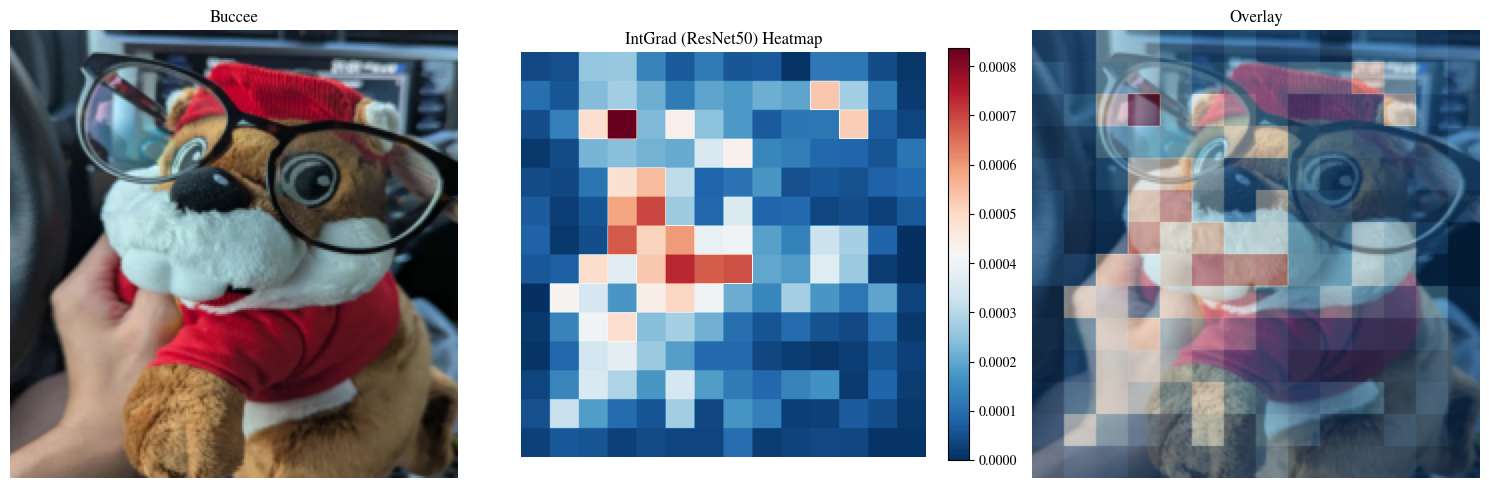

In [6]:
# ResNet50 with IntGrad
print("Running Integrated Gradients on ResNet50...")
intgrad_image = IntGradImage(n_steps=50, patch_size=16)  # Using patch_size for segmentation
intgrad_resnet_exp = intgrad_image.explain(resnet_model, resnet_image)
print(f"Target class: {intgrad_resnet_exp.metadata['target']}")
print(f"Number of segments: {intgrad_resnet_exp.metadata['num_segments']}")
print(f"Segments shape: {intgrad_resnet_exp.segments.shape}")
visualize_image_attribution(resnet_image, intgrad_resnet_exp.attributions, "IntGrad (ResNet50)")

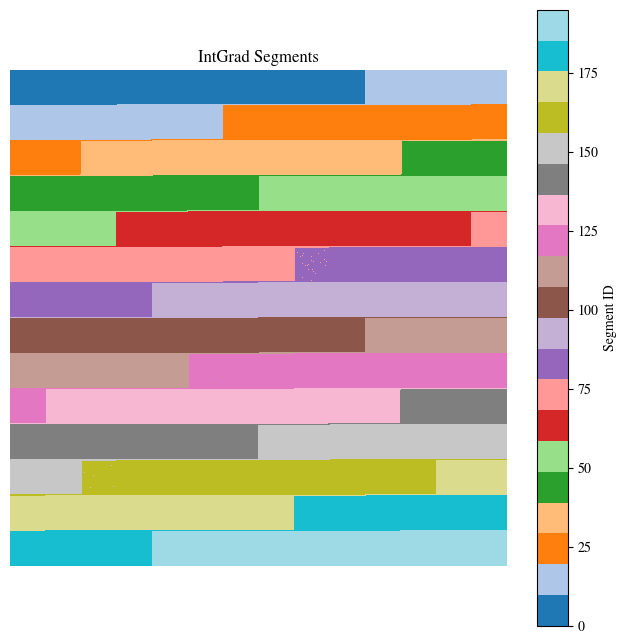

IntGrad now computes attributions at patch level by default!
Notice how the attribution map shows uniform values within each 16x16 patch.


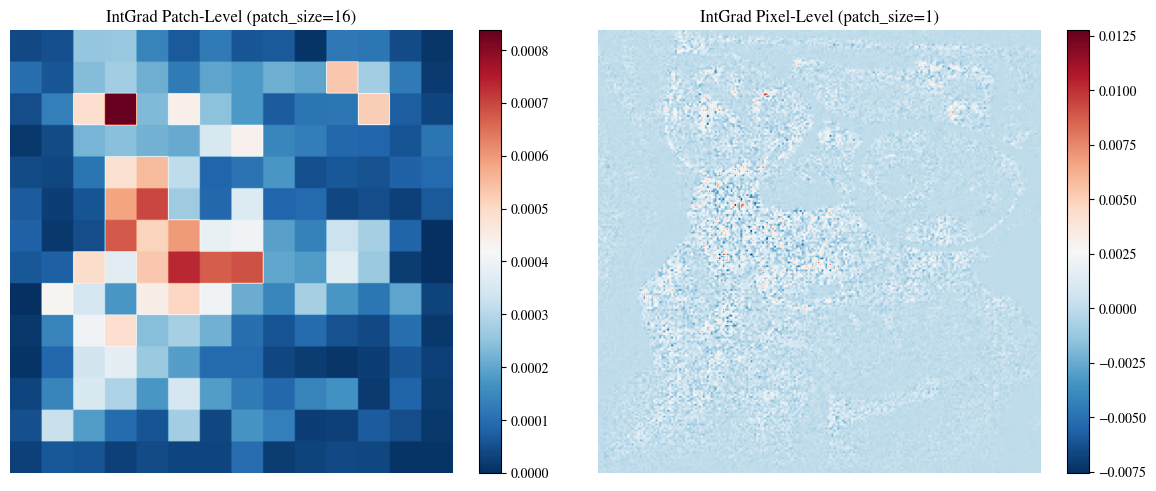

In [7]:
# Visualize IntGrad segments - now with patch-level attributions!
visualize_segments(intgrad_resnet_exp.segments, "IntGrad Segments")

# Show that IntGrad now produces clean patch-level attributions like LIME
print("IntGrad now computes attributions at patch level by default!")
print("Notice how the attribution map shows uniform values within each 16x16 patch.")

# For comparison, let's also create a pixel-level version
intgrad_pixel = IntGradImage(n_steps=20, patch_size=1)  # pixel-level
intgrad_pixel_exp = intgrad_pixel.explain(resnet_model, resnet_image)

# Compare patch vs pixel level
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Patch-level (default)
attr_patch = intgrad_resnet_exp.attributions.mean(dim=0).detach().cpu().numpy()
im1 = ax1.imshow(attr_patch, cmap='RdBu_r')
ax1.set_title("IntGrad Patch-Level (patch_size=16)")
ax1.axis('off')
plt.colorbar(im1, ax=ax1, fraction=0.046)

# Pixel-level
attr_pixel = intgrad_pixel_exp.attributions.mean(dim=0).detach().cpu().numpy()
im2 = ax2.imshow(attr_pixel, cmap='RdBu_r')
ax2.set_title("IntGrad Pixel-Level (patch_size=1)")
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046)

plt.tight_layout()
plt.show()

Running Integrated Gradients on GPT-2...


GPT2ForSequenceClassification will not detect padding tokens in `inputs_embeds`. Results may be unexpected if using padding tokens in conjunction with `inputs_embeds.`


Target class: 0
Number of segments: 13


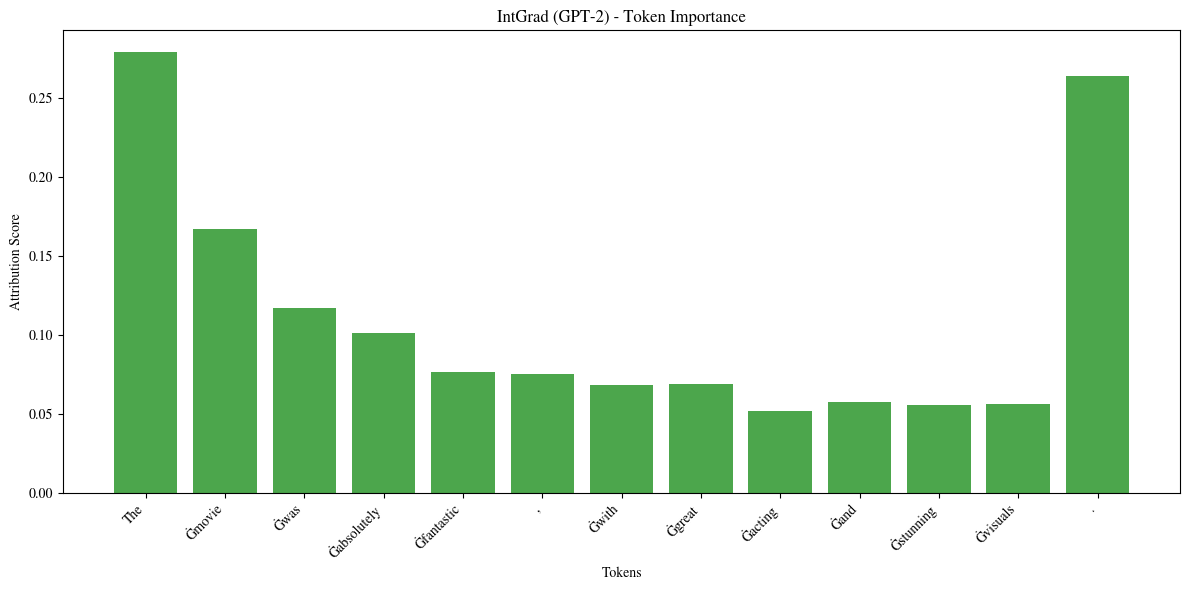

In [8]:
# GPT-2 with IntGrad
print("Running Integrated Gradients on GPT-2...")
intgrad_text = IntGradText(embedding_layer=gpt2_config["embedding_layer"], n_steps=50)
intgrad_text_exp = intgrad_text.explain(gpt2_model, input_ids)
print(f"Target class: {intgrad_text_exp.metadata['target']}")
print(f"Number of segments: {intgrad_text_exp.metadata['num_segments']}")
visualize_text_attribution(tokens, intgrad_text_exp.attributions, "IntGrad (GPT-2)")

Running LIME on ResNet50...
Target class: 413
R² score: 0.8116
Number of segments: 196
Segments shape: torch.Size([3, 224, 224])


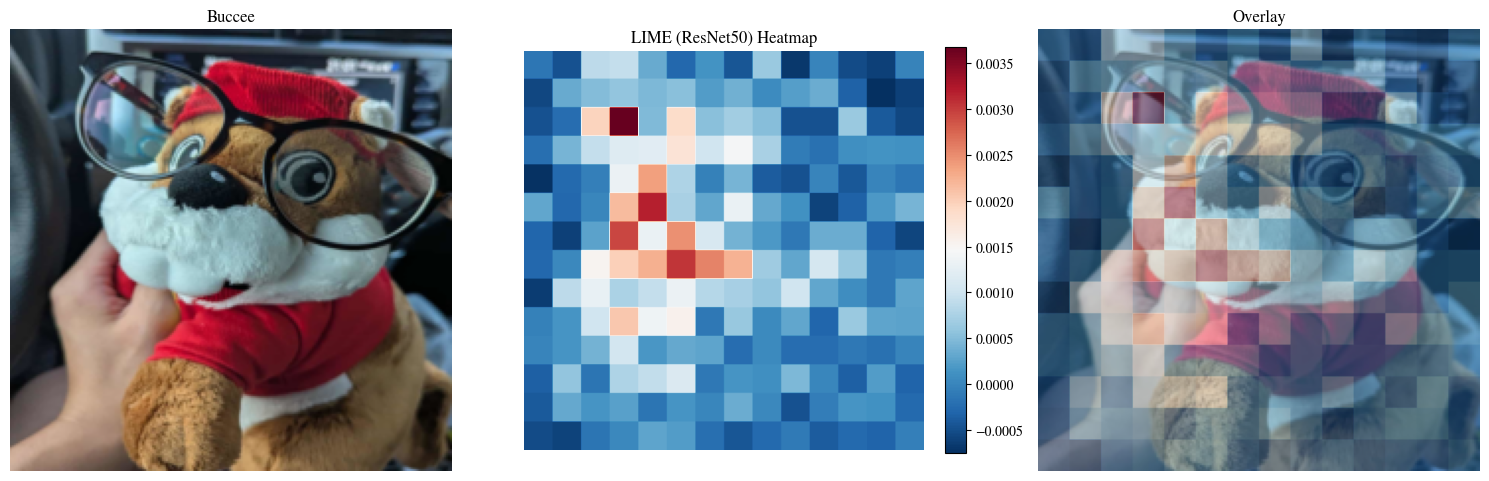

In [9]:
# ResNet50 with LIME
print("Running LIME on ResNet50...")
lime_image = LimeImage(n_samples=1000, patch_size=16)  # Now using patch_size instead of n_segments
lime_resnet_exp = lime_image.explain(resnet_model, resnet_image)
print(f"Target class: {lime_resnet_exp.metadata['target']}")
print(f"R² score: {lime_resnet_exp.r2_score:.4f}")
print(f"Number of segments: {lime_resnet_exp.metadata['num_segments']}")
print(f"Segments shape: {lime_resnet_exp.segments.shape}")
visualize_image_attribution(resnet_image, lime_resnet_exp.attributions, "LIME (ResNet50)")

## 2. LIME

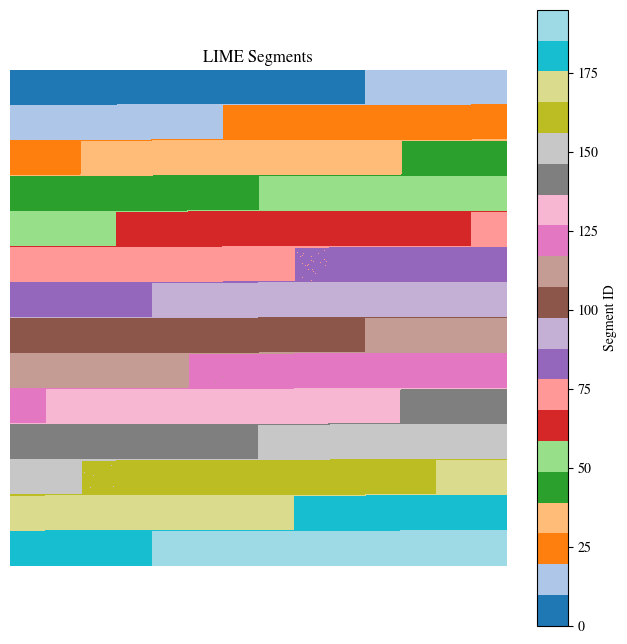

Input shape: torch.Size([3, 224, 224])
Segments shape: torch.Size([3, 224, 224])
✓ Segments shape matches input shape!


In [10]:
# Visualize LIME segments (now matches input shape)
if lime_resnet_exp.segments is not None:
    visualize_segments(lime_resnet_exp.segments, "LIME Segments")
    # Show that segments match input shape
    print(f"Input shape: {resnet_image.shape}")
    print(f"Segments shape: {lime_resnet_exp.segments.shape}")
    print("✓ Segments shape matches input shape!")

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


Running LIME on GPT-2...
Target class: 1
R² score: 0.7535
Number of segments: 13


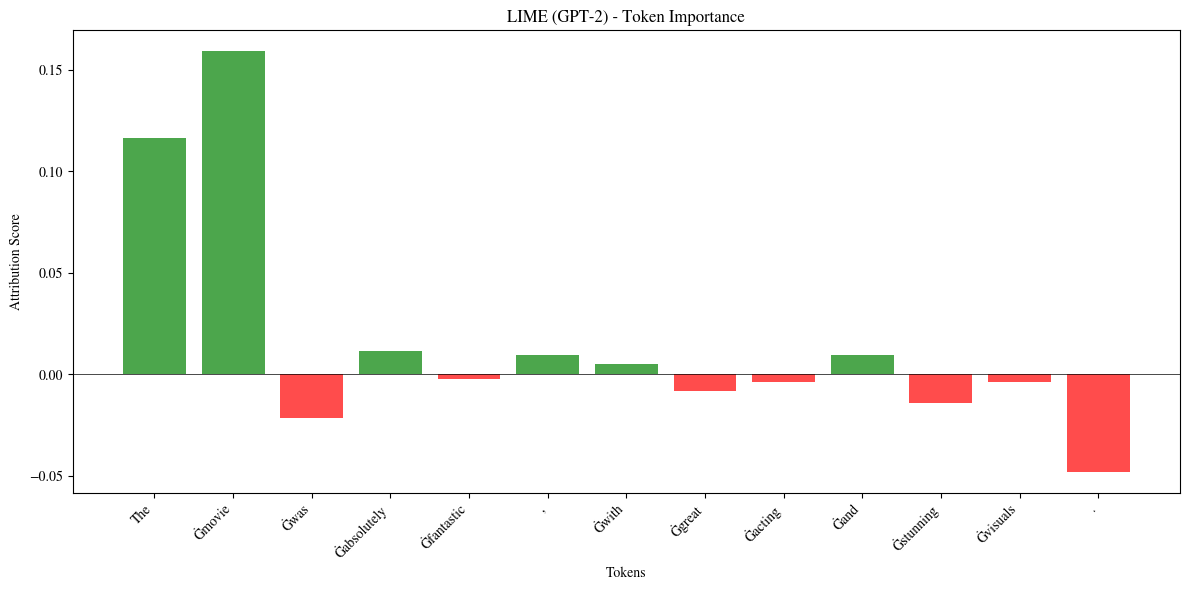

In [11]:
# GPT-2 with LIME
print("Running LIME on GPT-2...")
lime_text = LimeText(
    embedding_layer=gpt2_config["embedding_layer"],
    n_samples=1000,
    mask_token_id=tokenizer.pad_token_id or 0
)
lime_text_exp = lime_text.explain(gpt2_model, input_ids)
print(f"Target class: {lime_text_exp.metadata['target']}")
print(f"R² score: {lime_text_exp.r2_score:.4f}")
print(f"Number of segments: {lime_text_exp.metadata['num_segments']}")
visualize_text_attribution(tokens, lime_text_exp.attributions, "LIME (GPT-2)")

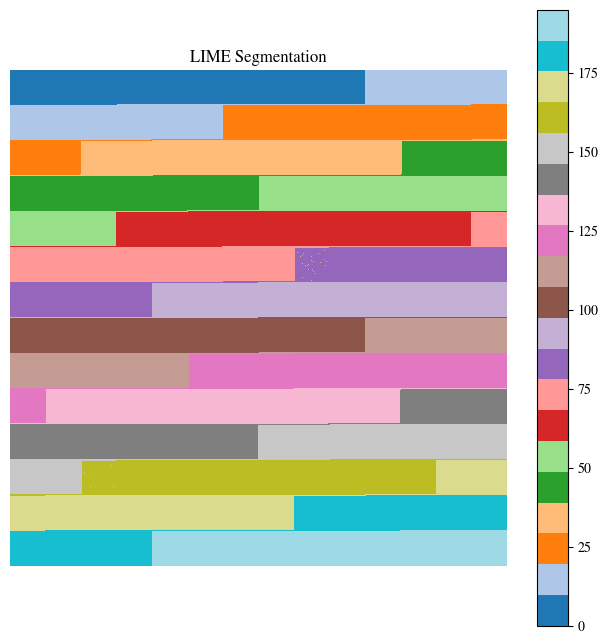

In [12]:
# Visualize LIME segments
if lime_resnet_exp.segments is not None:
    plt.figure(figsize=(8, 8))
    plt.imshow(lime_resnet_exp.segments[0].cpu().numpy(), cmap='tab20')
    plt.title("LIME Segmentation")
    plt.colorbar()
    plt.axis('off')
    plt.show()

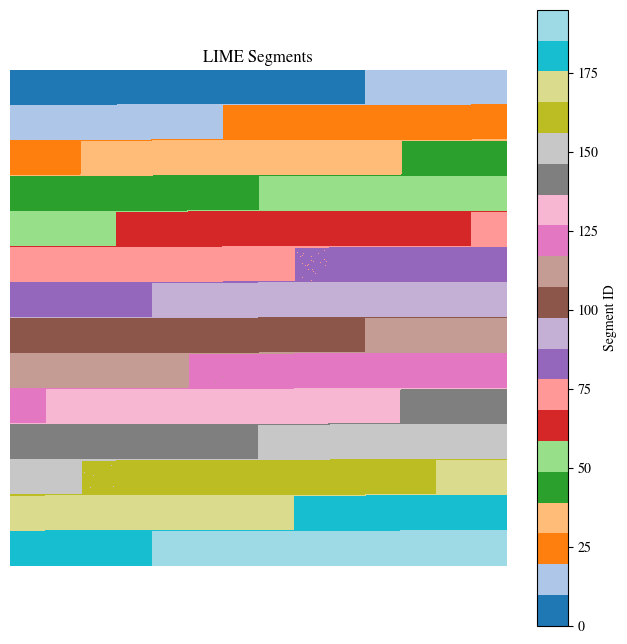

Input shape: torch.Size([3, 224, 224])
Segments shape: torch.Size([3, 224, 224])
✓ Segments shape matches input shape!


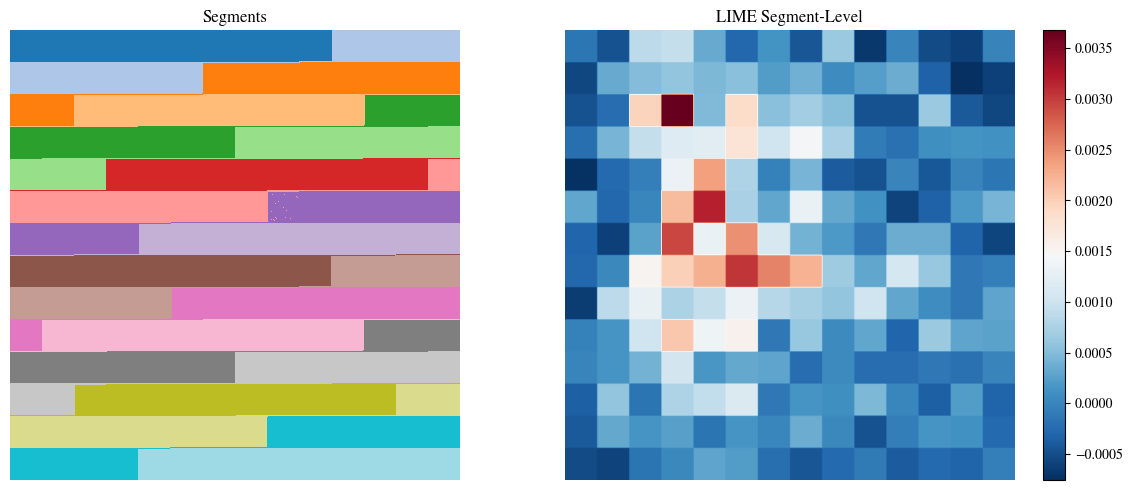

Top 5 segments by importance: [31, 74, 103, 87, 104]
Their attribution values: [0.0036754910834133625, 0.0031777839176356792, 0.003048657439649105, 0.0029325492214411497, 0.002562121953815222]


In [13]:
# Visualize LIME segments (now matches input shape)
if lime_resnet_exp.segments is not None:
    # Use the visualize_segments function which handles multi-channel segments
    visualize_segments(lime_resnet_exp.segments, "LIME Segments")
    
    # Show that segments match input shape
    print(f"Input shape: {resnet_image.shape}")
    print(f"Segments shape: {lime_resnet_exp.segments.shape}")
    print("✓ Segments shape matches input shape!")
    
    # Also show segment-level attributions
    visualize_segment_attributions(lime_resnet_exp.attributions, lime_resnet_exp.segments, "LIME Segment-Level")

## 3. SHAP

Running SHAP on GPT-2...
Target class: 1
Expected value: 0.4134
Base value: 0.4047


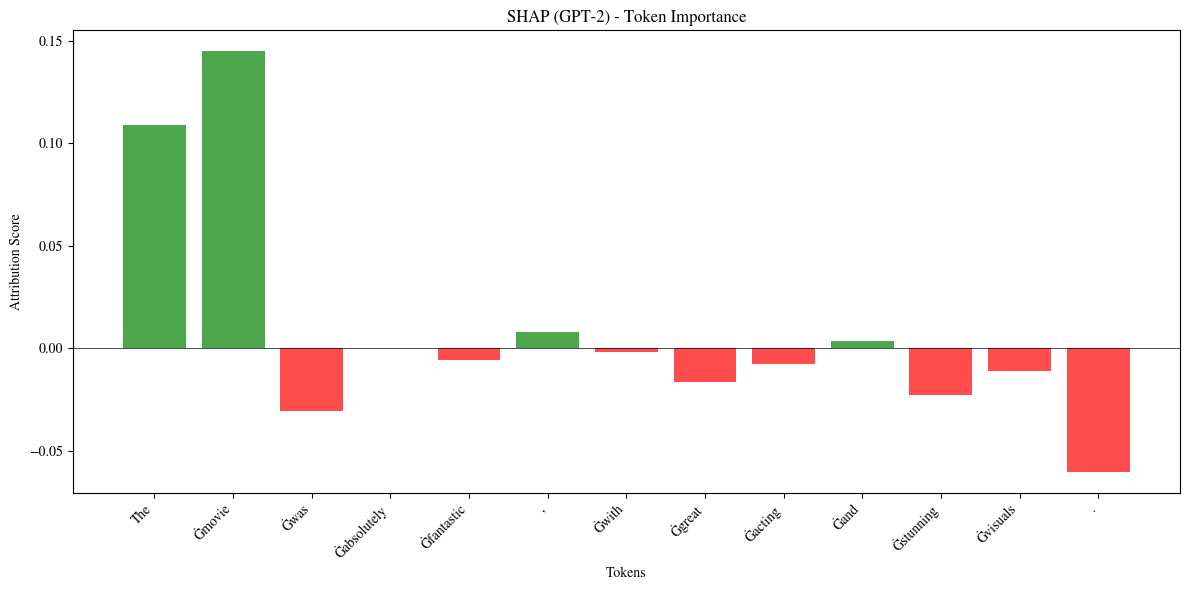

In [14]:
# GPT-2 with SHAP
print("Running SHAP on GPT-2...")
shap_text = ShapText(
    embedding_layer=gpt2_config["embedding_layer"],
    n_samples=1000,
    mask_token_id=tokenizer.pad_token_id or 0
)
shap_text_exp = shap_text.explain(gpt2_model, input_ids)
print(f"Target class: {shap_text_exp.metadata['target']}")
print(f"Expected value: {shap_text_exp.expected_value:.4f}")
print(f"Base value: {shap_text_exp.base_value:.4f}")
visualize_text_attribution(tokens, shap_text_exp.attributions, "SHAP (GPT-2)")

Running SHAP on ResNet50...
Target class: 413
Number of segments: 196
Segments shape: torch.Size([3, 224, 224])


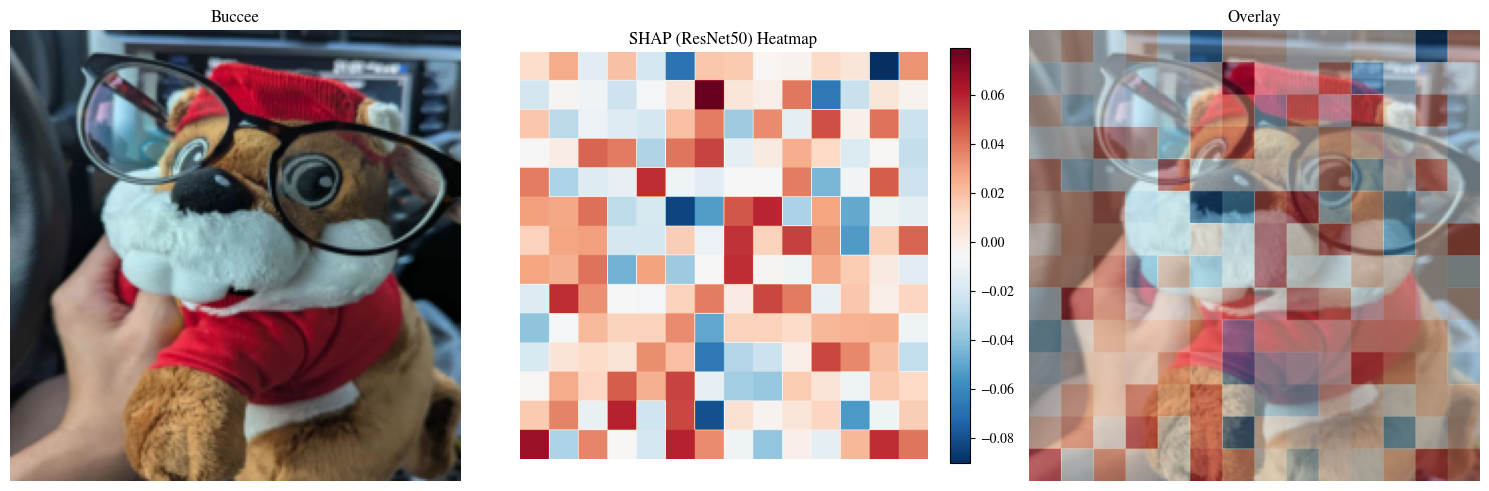

In [15]:
# ResNet50 with SHAP
print("Running SHAP on ResNet50...")
shap_image = ShapImage(n_samples=1000, patch_size=16)
shap_resnet_exp = shap_image.explain(resnet_model, resnet_image)
print(f"Target class: {shap_resnet_exp.metadata['target']}")
print(f"Number of segments: {shap_resnet_exp.metadata['num_segments']}")
print(f"Segments shape: {shap_resnet_exp.segments.shape}")

# Visualize
visualize_image_attribution(resnet_image, shap_resnet_exp.attributions, "SHAP (ResNet50)")

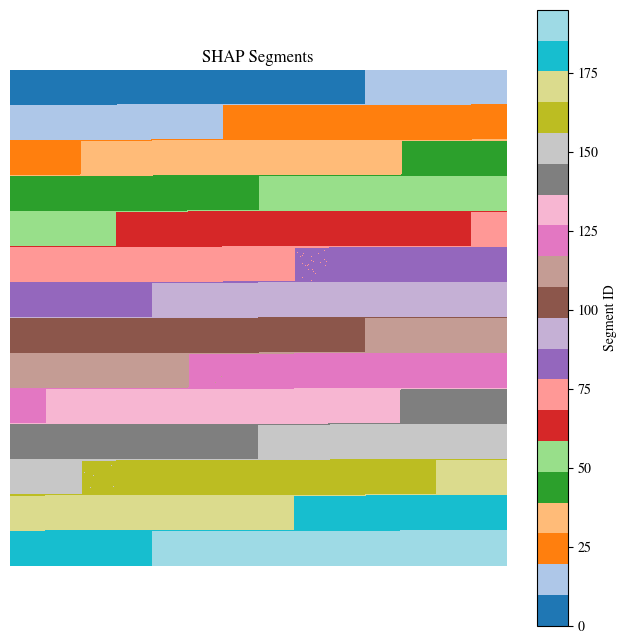

In [16]:
# Visualize SHAP segments
visualize_segments(shap_resnet_exp.segments, "SHAP Segments")

Running GradCAM on ResNet50...
Target class: 413
Selected layer: layer4.2.conv3
Number of segments: 196
Segments shape: torch.Size([3, 224, 224])


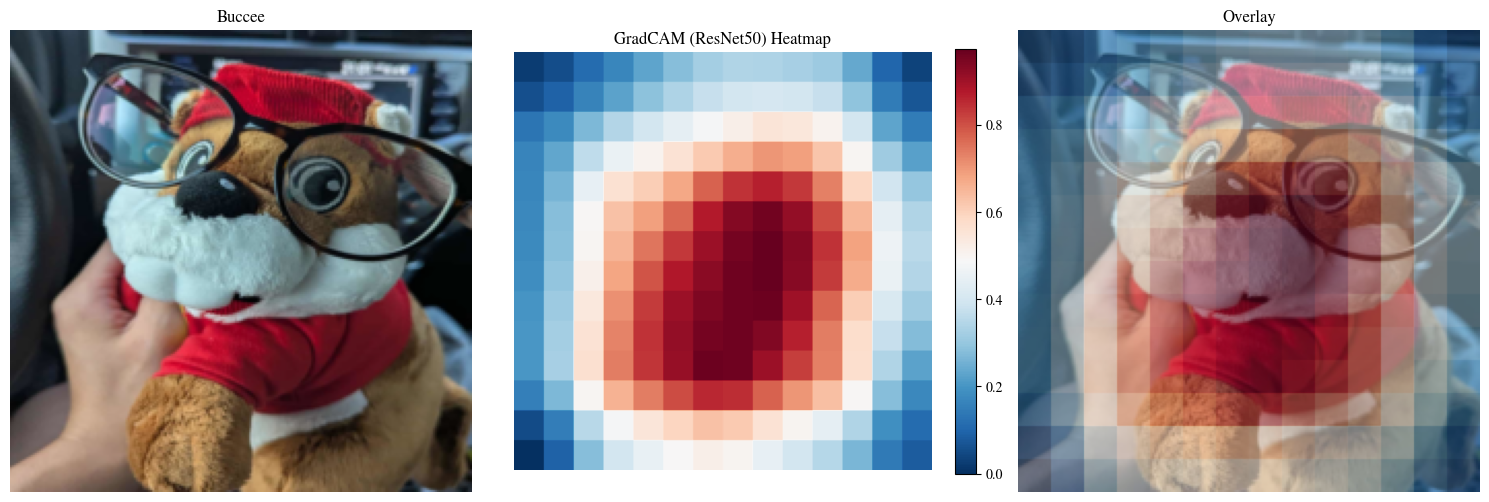

In [17]:
# ResNet50 with GradCAM
print("Running GradCAM on ResNet50...")
gradcam_image = GradCAMImage(patch_size=16)  # Add patch_size for segmentation
gradcam_resnet_exp = gradcam_image.explain(resnet_model, resnet_image)
print(f"Target class: {gradcam_resnet_exp.metadata['target']}")
print(f"Selected layer: {gradcam_resnet_exp.metadata['layer_name']}")
print(f"Number of segments: {gradcam_resnet_exp.metadata['num_segments']}")
print(f"Segments shape: {gradcam_resnet_exp.segments.shape}")
visualize_image_attribution(resnet_image, gradcam_resnet_exp.attributions, "GradCAM (ResNet50)")

Running GradCAM on ResNet50...
Target class: 413
Selected layer: layer4.2.conv3


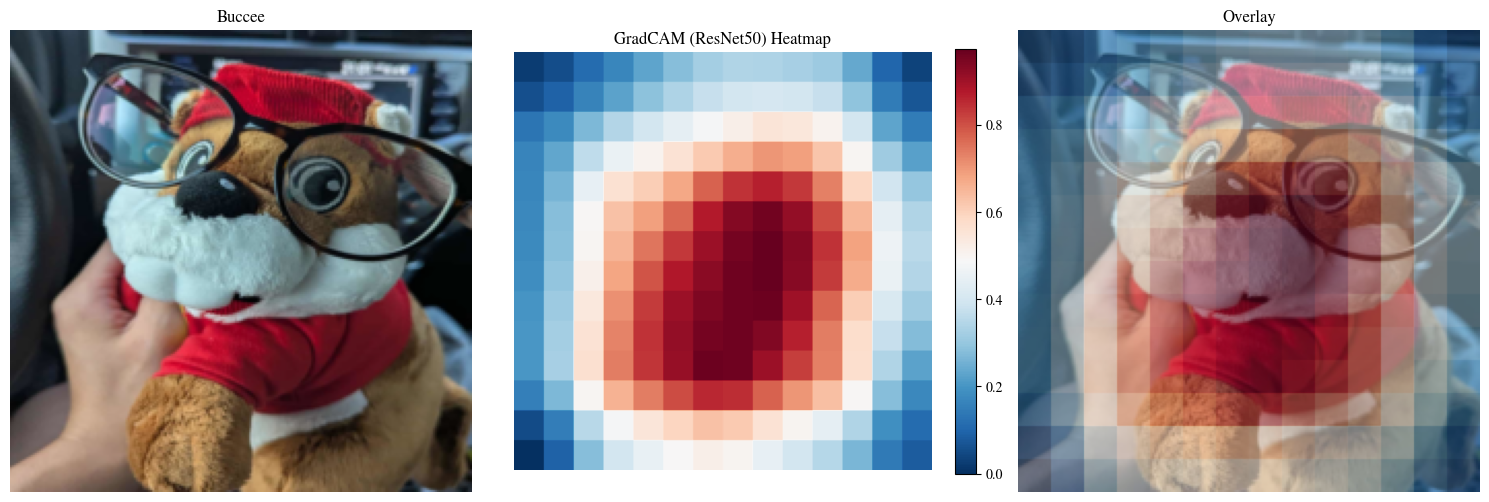

In [18]:
# ResNet50 with GradCAM
print("Running GradCAM on ResNet50...")
gradcam_image = GradCAMImage()  # Auto-select layer
gradcam_resnet_exp = gradcam_image.explain(resnet_model, resnet_image)
print(f"Target class: {gradcam_resnet_exp.metadata['target']}")
print(f"Selected layer: {gradcam_resnet_exp.metadata['layer_name']}")
visualize_image_attribution(resnet_image, gradcam_resnet_exp.attributions, "GradCAM (ResNet50)")

Running GradCAM on GPT-2...
Target class: 1
Method: embedding_gradients


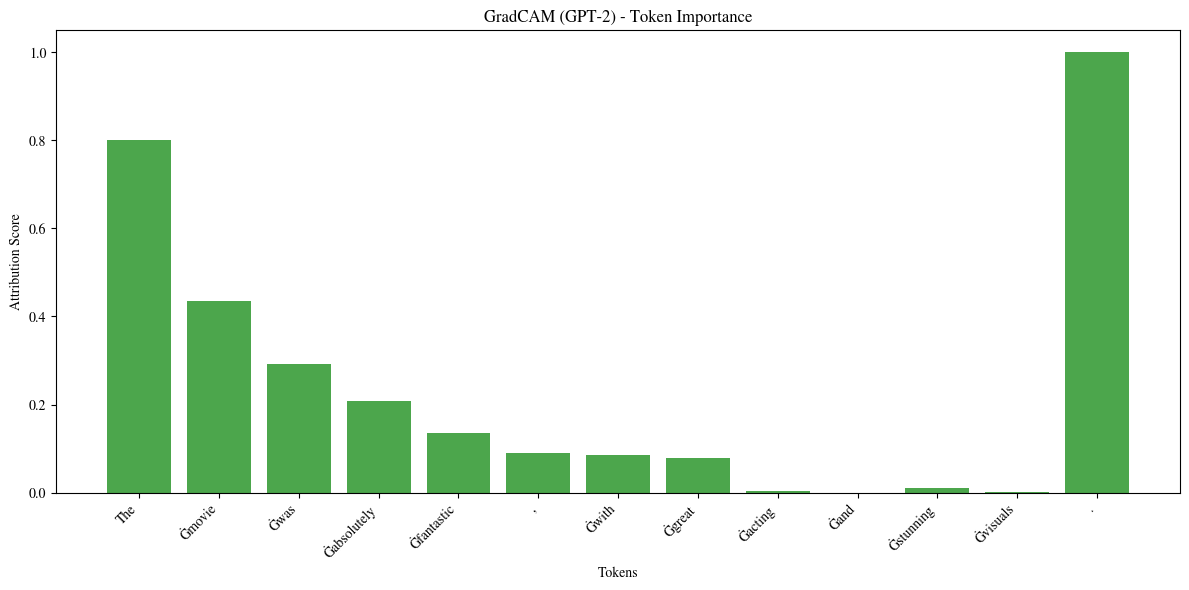

In [19]:
# GPT-2 with GradCAM (embedding gradients)
print("Running GradCAM on GPT-2...")
gradcam_text = GradCAMText(embedding_layer=gpt2_config["embedding_layer"])
gradcam_text_exp = gradcam_text.explain(gpt2_model, input_ids)
print(f"Target class: {gradcam_text_exp.metadata['target']}")
print(f"Method: {gradcam_text_exp.metadata['method']}")
visualize_text_attribution(tokens, gradcam_text_exp.attributions, "GradCAM (GPT-2)")

## Comparison: All Methods Side by Side

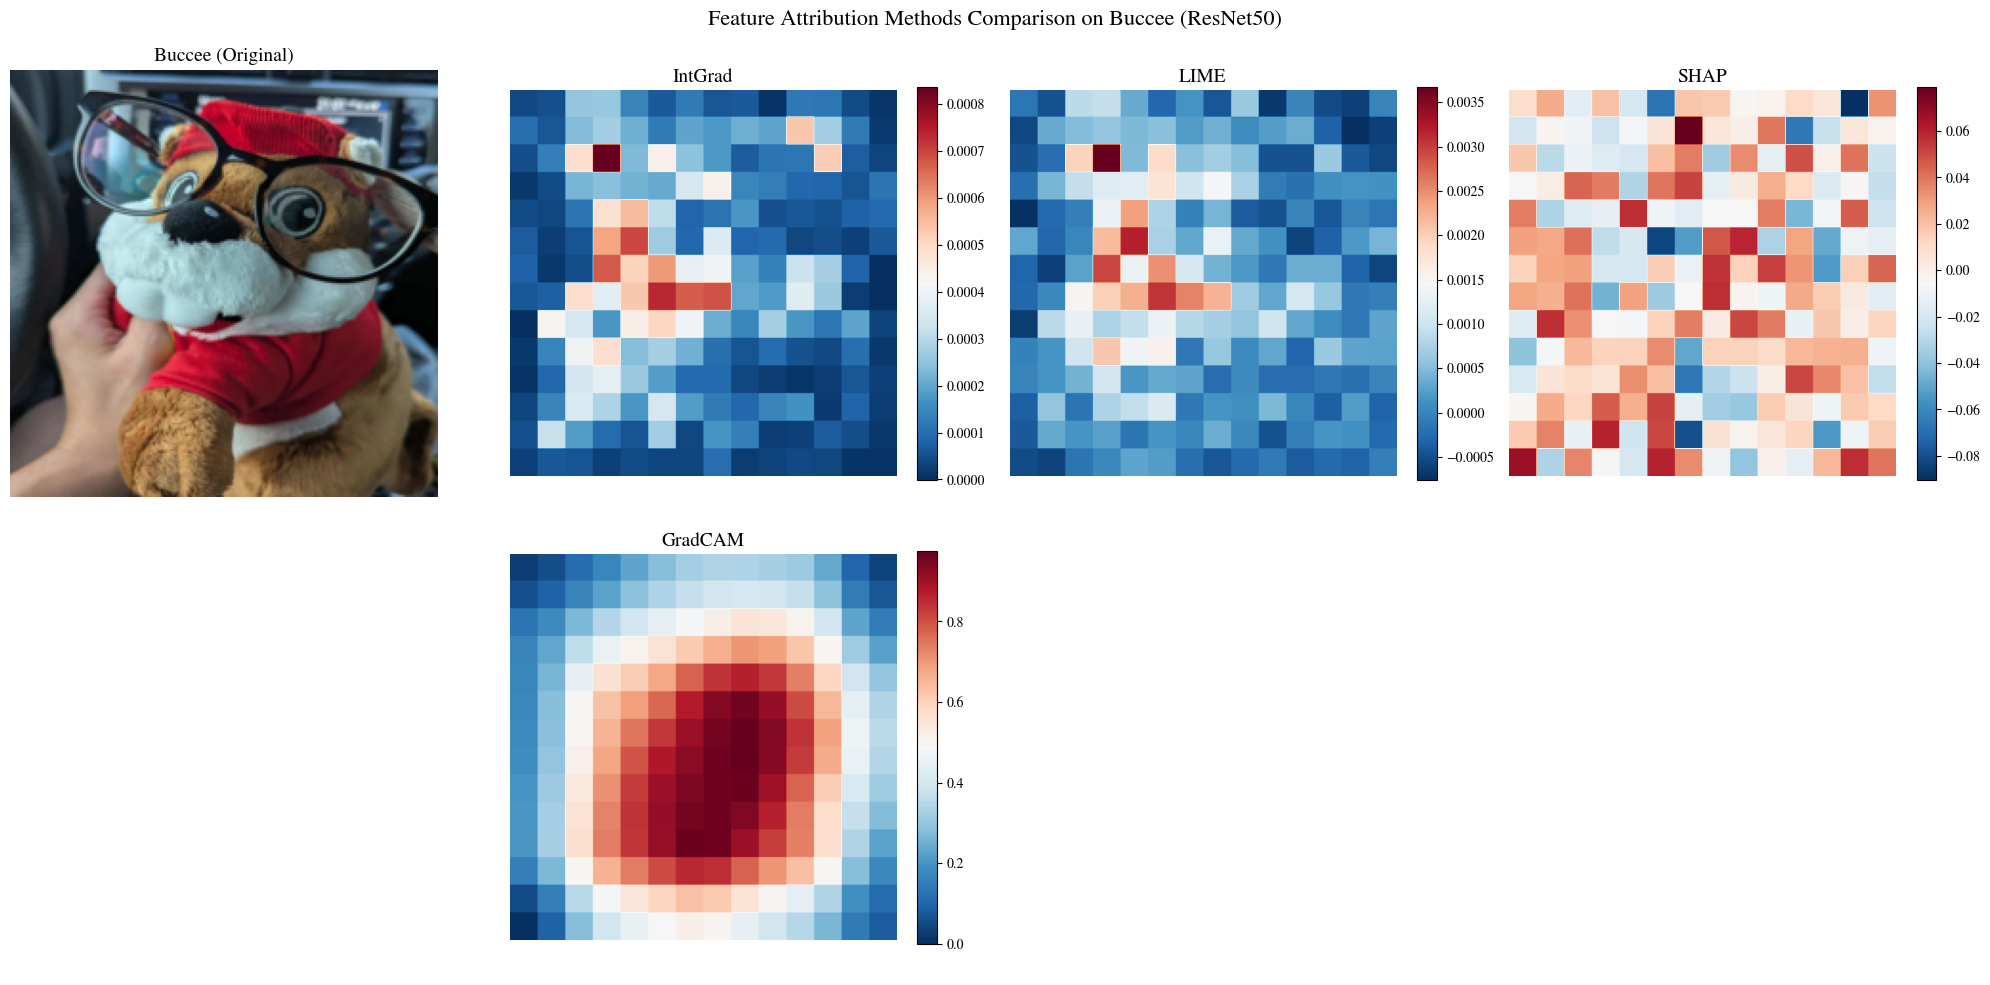

In [20]:
# Compare all vision methods on ResNet50
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Original buccee image
img_display = resnet_image.permute(1, 2, 0).detach().cpu().numpy()
img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())

# Plot original
axes[0, 0].imshow(img_display)
axes[0, 0].set_title("Buccee (Original)", fontsize=14)
axes[0, 0].axis('off')
axes[1, 0].axis('off')

# Plot attributions
methods = [
    ("IntGrad", intgrad_resnet_exp.attributions),
    ("LIME", lime_resnet_exp.attributions),
    ("SHAP", shap_resnet_exp.attributions),
    ("GradCAM", gradcam_resnet_exp.attributions)
]

for i, (name, attr) in enumerate(methods, 1):
    if i < 4:
        ax = axes[0, i]
    else:
        ax = axes[1, i-3]
    
    attr_avg = attr.mean(dim=0).detach().cpu().numpy()
    im = ax.imshow(attr_avg, cmap='RdBu_r')
    ax.set_title(name, fontsize=14)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

# Hide unused
axes[1, 1].axis('off')
axes[1, 2].axis('off')
axes[1, 3].axis('off')

plt.suptitle("Feature Attribution Methods Comparison on Buccee (ResNet50)", fontsize=16)
plt.tight_layout()
plt.show()

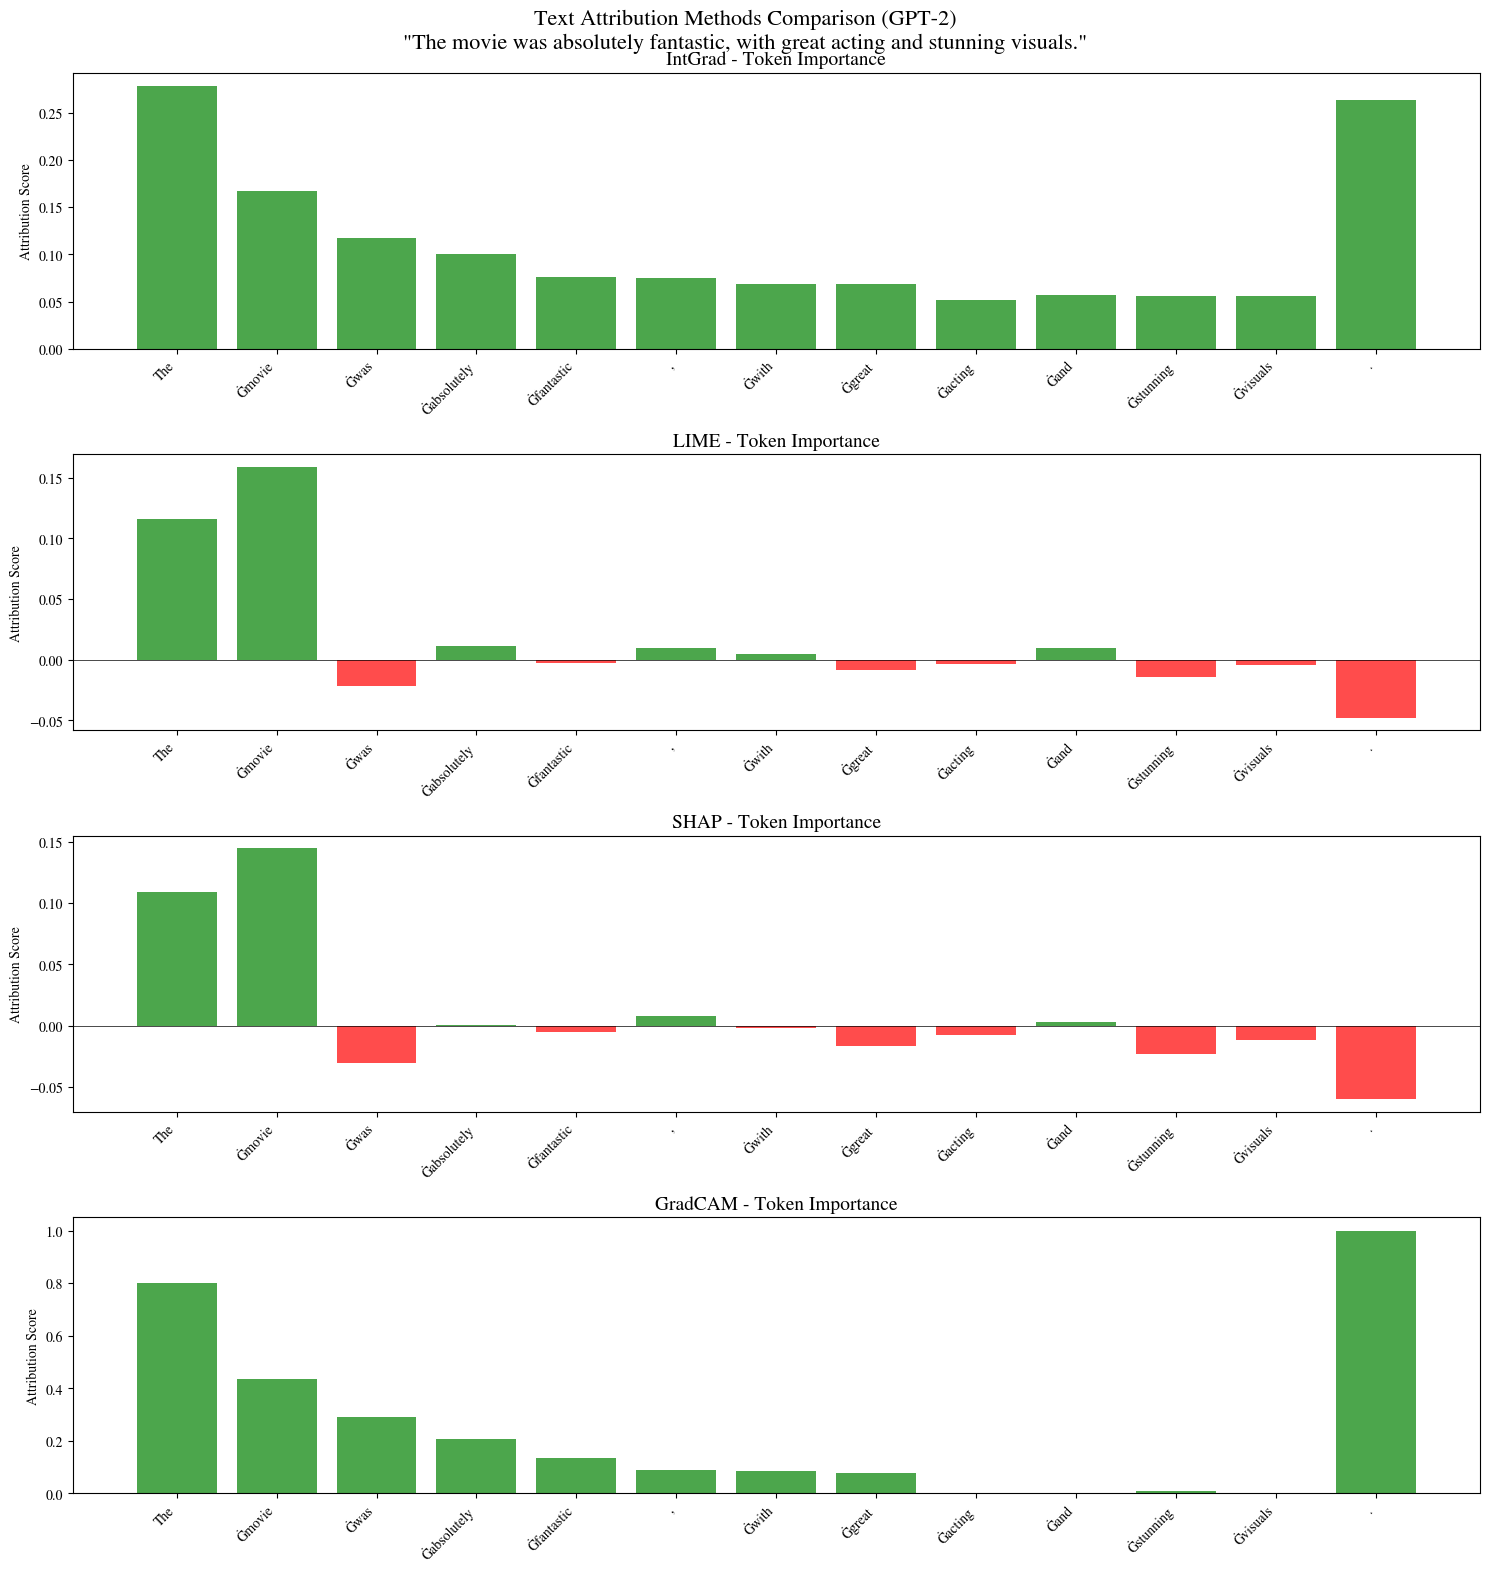

In [21]:
# Compare text methods
fig, axes = plt.subplots(4, 1, figsize=(15, 16))

text_methods = [
    ("IntGrad", intgrad_text_exp.attributions),
    ("LIME", lime_text_exp.attributions),
    ("SHAP", shap_text_exp.attributions),
    ("GradCAM", gradcam_text_exp.attributions)
]

for i, (name, attr) in enumerate(text_methods):
    ax = axes[i]
    attr_values = attr.detach().cpu().numpy()
    
    x = np.arange(len(tokens))
    colors = ['red' if v < 0 else 'green' for v in attr_values]
    bars = ax.bar(x, attr_values, color=colors, alpha=0.7)
    
    ax.set_xticks(x)
    ax.set_xticklabels(tokens, rotation=45, ha='right')
    ax.set_ylabel('Attribution Score')
    ax.set_title(f'{name} - Token Importance', fontsize=14)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.suptitle(f'Text Attribution Methods Comparison (GPT-2)\n"{test_text}"', fontsize=16)
plt.tight_layout()
plt.show()

## Summary Statistics

In [22]:
# Compute statistics for each method
print("Attribution Statistics (ResNet50)")
print("=" * 50)

for name, attr in methods:
    attr_flat = attr.flatten().detach().cpu().numpy()
    print(f"\n{name}:")
    print(f"  Mean: {attr_flat.mean():.6f}")
    print(f"  Std:  {attr_flat.std():.6f}")
    print(f"  Min:  {attr_flat.min():.6f}")
    print(f"  Max:  {attr_flat.max():.6f}")
    print(f"  % Positive: {(attr_flat > 0).mean() * 100:.1f}%")

print("\n" + "=" * 50)
print("Attribution Statistics (GPT-2)")
print("=" * 50)

for name, attr in text_methods:
    attr_values = attr.detach().cpu().numpy()
    print(f"\n{name}:")
    print(f"  Mean: {attr_values.mean():.6f}")
    print(f"  Std:  {attr_values.std():.6f}")
    print(f"  Min:  {attr_values.min():.6f}")
    print(f"  Max:  {attr_values.max():.6f}")
    print(f"  % Positive: {(attr_values > 0).mean() * 100:.1f}%")

Attribution Statistics (ResNet50)

IntGrad:
  Mean: 0.000177
  Std:  0.000204
  Min:  -0.000073
  Max:  0.001073
  % Positive: 94.2%

LIME:
  Mean: 0.000353
  Std:  0.000799
  Min:  -0.000756
  Max:  0.003675
  % Positive: 63.3%

SHAP:
  Mean: 0.005021
  Std:  0.031065
  Min:  -0.090184
  Max:  0.079053
  % Positive: 54.1%

GradCAM:
  Mean: 0.508317
  Std:  0.271301
  Min:  0.000000
  Max:  0.975426
  % Positive: 99.5%

Attribution Statistics (GPT-2)

IntGrad:
  Mean: 0.110508
  Std:  0.075218
  Min:  0.051937
  Max:  0.278894
  % Positive: 100.0%

LIME:
  Mean: 0.016169
  Std:  0.054672
  Min:  -0.047885
  Max:  0.159138
  % Positive: 46.2%

SHAP:
  Mean: 0.008384
  Std:  0.053756
  Min:  -0.060153
  Max:  0.144747
  % Positive: 38.5%

GradCAM:
  Mean: 0.241397
  Std:  0.308910
  Min:  0.000000
  Max:  1.000000
  % Positive: 92.3%


## Method-Specific Features

In [23]:
# Demonstrate LIME's local model quality
print("LIME R² Scores (Model Fit Quality):")
print(f"  ResNet50: {lime_resnet_exp.r2_score:.4f}")
print(f"  GPT-2: {lime_text_exp.r2_score:.4f}")

# Demonstrate SHAP's expected values
print("\nSHAP Expected Values:")
print(f"  ResNet50: {shap_resnet_exp.expected_value:.4f} (base: {shap_resnet_exp.base_value:.4f})")
print(f"  GPT-2: {shap_text_exp.expected_value:.4f} (base: {shap_text_exp.base_value:.4f})")

# Demonstrate IntGrad convergence
print("\nIntegrated Gradients Convergence Check:")
intgrad_conv = intgrad_image.explain(resnet_model, resnet_image, return_convergence_delta=True)
print(f"  Convergence delta: {intgrad_conv.convergence_delta:.6f}")
print(f"  (Lower is better, < 1.0 is good)")

LIME R² Scores (Model Fit Quality):
  ResNet50: 0.8116
  GPT-2: 0.7535

SHAP Expected Values:
  ResNet50: 0.0048 (base: 0.0010)
  GPT-2: 0.4134 (base: 0.4047)

Integrated Gradients Convergence Check:
  Convergence delta: 0.539907
  (Lower is better, < 1.0 is good)


## Conclusion

This notebook demonstrated all four implemented feature attribution methods:

1. **Integrated Gradients**: Gradient-based method that integrates gradients along a path from baseline to input
2. **LIME**: Model-agnostic method using local linear approximations
3. **SHAP**: Game-theoretic approach based on Shapley values
4. **GradCAM**: Gradient-based method specifically designed for CNNs

**NEW FEATURES:**
- **Segments field**: All explanations now include a `segments` tensor matching input shape
- **Consistent segmentation**: Methods with same `patch_size` produce identical segments
- **Custom segmentation**: Support for custom segmentation functions (e.g., quickshift)
- **Segment-level analysis**: Aggregate and compare attributions at segment level

Each method has its strengths:
- **Speed**: GradCAM is fastest, followed by IntGrad
- **Model-agnostic**: LIME and SHAP work with any model
- **Theoretical guarantees**: SHAP provides Shapley value properties
- **Visual quality**: GradCAM often provides smooth, interpretable heatmaps for CNNs
- **Segment support**: All methods now support segment-based analysis

All methods follow the same low-abstraction API pattern:
```python
explainer = MethodName(patch_size=16, segmentation_fn=custom_fn)  # NEW: segmentation options
explanation = explainer.explain(model, input, target)
# Access segments: explanation.segments
```

## NEW: Segments Feature Demonstration

All methods now include a `segments` field that provides segmentation information. This enables:
1. Segment-level attribution analysis
2. Consistent segmentation across methods
3. Custom segmentation functions
4. Better downstream integration

### Attribution Granularity Update

**IntGrad now computes attributions at patch level by default!**

- **LIME**: Computes attributions at the **segment level** - all pixels in a segment get the same value
- **IntGrad**: Now computes at **patch level** by default (patch_size=16) - set patch_size=1 for pixel-level
- **SHAP**: Like LIME, works at the **segment level**
- **GradCAM**: Still computes at **pixel level** for fine-grained heatmaps

This makes IntGrad more consistent with LIME while preserving the option for pixel-level detail when needed.

### Important Note: Attribution Granularity

Different methods compute attributions at different granularities:

- **LIME**: Computes attributions at the **segment level** - all pixels in a segment get the same value
- **IntGrad, GradCAM**: Compute attributions at the **pixel level** - each pixel has its own value
- **SHAP**: Like LIME, works at the **segment level**

The `segments` field is provided for all methods to enable consistent downstream analysis. For pixel-level methods (IntGrad, GradCAM), you can:
1. Use the fine-grained pixel attributions directly
2. Aggregate to segment-level using `aggregate_attributions_by_segments()` when needed

This design preserves the full resolution of gradient-based methods while enabling segment-based analysis when desired.

In [24]:
# 2. Compare segment-level attributions across methods
print("\n=== Segment-Level Attribution Comparison ===")

# Get all explanations
explanations = {
    "IntGrad": intgrad_resnet_exp,
    "LIME": lime_resnet_exp,
    "SHAP": shap_resnet_exp
}

# Compare attributions for segment 0
segment_0_comparison = compare_segment_attributions(explanations, segment_id=0)
print("\nSegment 0 attribution values:")
for method, value in segment_0_comparison.items():
    print(f"  {method}: {value:.6f}")

# Get top segments for each method
print("\nTop 3 segments by method:")
for name, exp in explanations.items():
    top_segs = get_top_segments(exp.attributions, exp.segments, k=3)
    seg_attrs = aggregate_attributions_by_segments(exp.attributions, exp.segments)
    values = [seg_attrs[i].item() for i in top_segs]
    print(f"  {name}: segments {top_segs.tolist()} with values {[f'{v:.4f}' for v in values]}")


=== Segment-Level Attribution Comparison ===

Segment 0 attribution values:
  IntGrad: 0.000040
  LIME: -0.000136
  SHAP: 0.009531

Top 3 segments by method:
  IntGrad: segments [31, 103, 74] with values ['0.0008', '0.0007', '0.0007']
  LIME: segments [31, 74, 103] with values ['0.0037', '0.0032', '0.0030']
  SHAP: segments [12, 75, 174] with values ['-0.0902', '-0.0831', '-0.0802']



=== Custom Segmentation ===
Quadrant segmentation on Buccee - Number of segments: 4


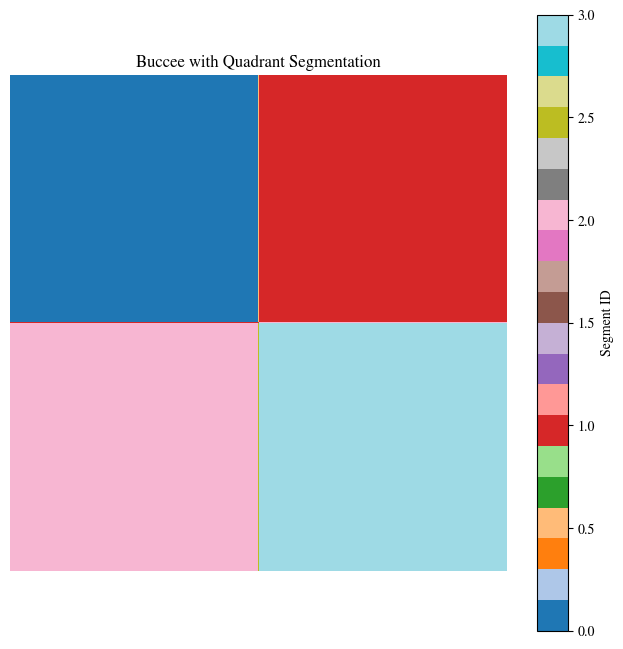

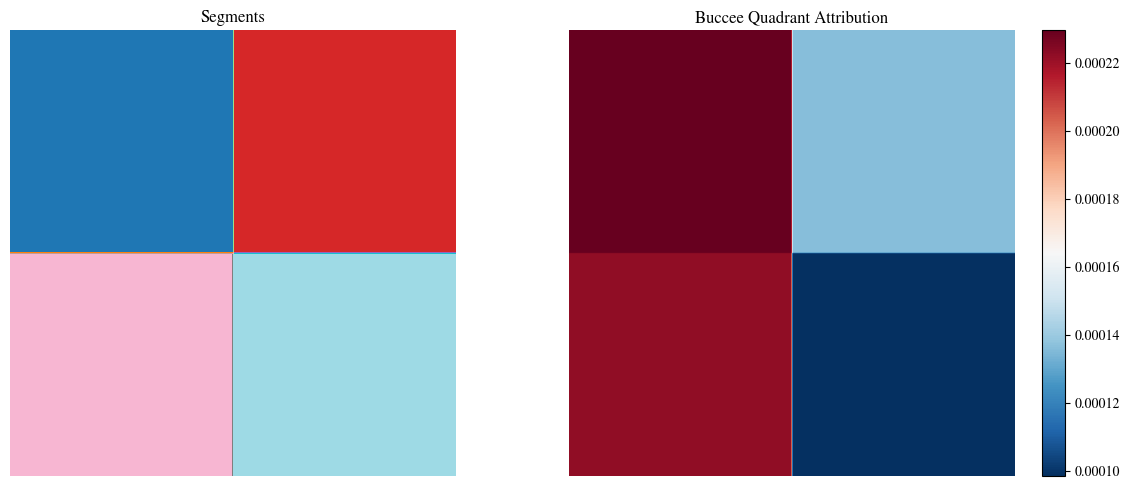

Top 5 segments by importance: [0, 2, 1, 3]
Their attribution values: [0.0002296869206475094, 0.00022215810895431787, 0.00013624240818899125, 9.858030534815043e-05]

=== Quickshift Segmentation on Buccee ===
Quickshift on Buccee - Number of segments: 62


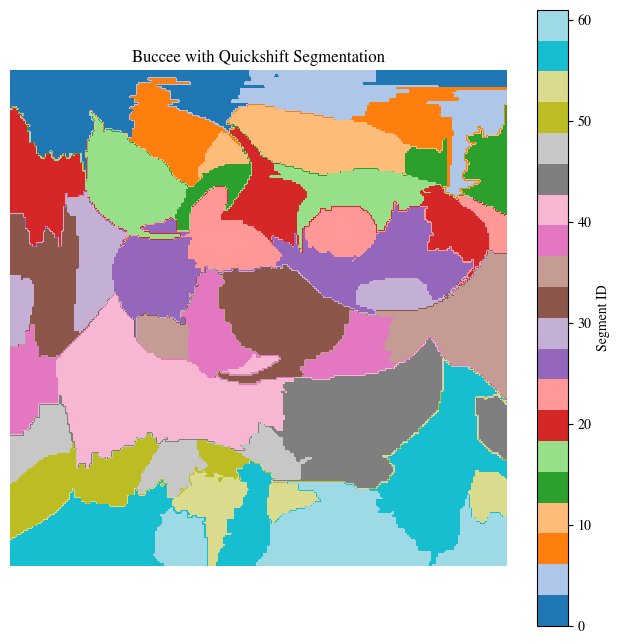

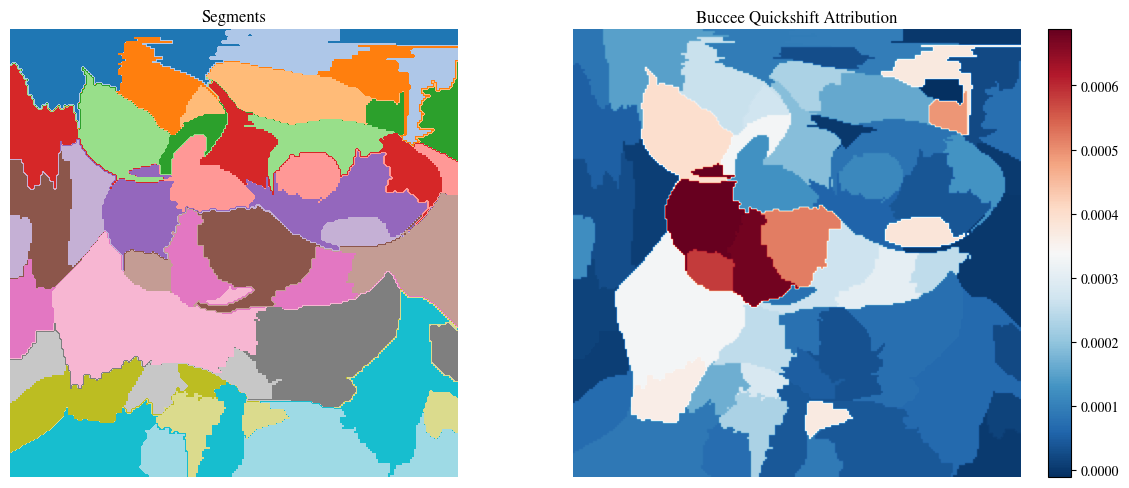

Top 5 segments by importance: [26, 37, 34, 31, 14]
Their attribution values: [0.0006876100087538362, 0.0006749805761501193, 0.0005837022908963263, 0.0005172423552721739, 0.000492874241899699]


In [25]:
# 3. Custom segmentation function
print("\n=== Custom Segmentation ===")

# Define a custom segmentation that creates 4 quadrants
def quadrant_segmentation(image):
    """Divide image into 4 quadrants."""
    h, w = image.shape[1], image.shape[2]
    segments = torch.zeros(h, w, dtype=torch.long)
    segments[:h//2, :w//2] = 0  # Top-left
    segments[:h//2, w//2:] = 1  # Top-right
    segments[h//2:, :w//2] = 2  # Bottom-left
    segments[h//2:, w//2:] = 3  # Bottom-right
    return segments

# Try quickshift if available
try:
    from skimage.segmentation import quickshift
    
    def quickshift_segmentation(image):
        """Advanced segmentation using quickshift."""
        img_np = image.detach().permute(1, 2, 0).cpu().numpy()
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
        segments = quickshift(img_np, kernel_size=3, max_dist=200, ratio=0.2)
        return torch.tensor(segments, device=image.device, dtype=torch.long)
    
    HAS_QUICKSHIFT = True
except ImportError:
    HAS_QUICKSHIFT = False
    print("Install scikit-image for quickshift segmentation")

# Use custom segmentation with IntGrad on buccee
intgrad_custom = IntGradImage(n_steps=20, segmentation_fn=quadrant_segmentation)
custom_exp = intgrad_custom.explain(resnet_model, resnet_image)

print(f"Quadrant segmentation on Buccee - Number of segments: {custom_exp.metadata['num_segments']}")
visualize_segments(custom_exp.segments, "Buccee with Quadrant Segmentation")
visualize_segment_attributions(custom_exp.attributions, custom_exp.segments, "Buccee Quadrant Attribution")

# Try quickshift if available
if HAS_QUICKSHIFT:
    print("\n=== Quickshift Segmentation on Buccee ===")
    intgrad_qs = IntGradImage(n_steps=20, segmentation_fn=quickshift_segmentation)
    qs_exp = intgrad_qs.explain(resnet_model, resnet_image)
    print(f"Quickshift on Buccee - Number of segments: {qs_exp.metadata['num_segments']}")
    visualize_segments(qs_exp.segments, "Buccee with Quickshift Segmentation")
    visualize_segment_attributions(qs_exp.attributions, qs_exp.segments, "Buccee Quickshift Attribution")

In [26]:
import time

# Benchmark execution times
print("Execution Time Comparison (ResNet50)")
print("=" * 40)

# IntGrad
start = time.time()
_ = IntGradImage(n_steps=20, patch_size=16).explain(resnet_model, resnet_image)
intgrad_time = time.time() - start
print(f"IntGrad (20 steps): {intgrad_time:.2f}s")

# LIME
start = time.time()
_ = LimeImage(n_samples=50, patch_size=16).explain(resnet_model, resnet_image)
lime_time = time.time() - start
print(f"LIME (50 samples): {lime_time:.2f}s")

# SHAP
start = time.time()
_ = ShapImage(n_samples=50, patch_size=16).explain(resnet_model, resnet_image)
shap_time = time.time() - start
print(f"SHAP (50 samples): {shap_time:.2f}s")

# GradCAM
start = time.time()
_ = GradCAMImage(patch_size=16).explain(resnet_model, resnet_image)
gradcam_time = time.time() - start
print(f"GradCAM: {gradcam_time:.2f}s")

print(f"\nFastest: GradCAM ({gradcam_time:.2f}s)")
print(f"Slowest: {max([(intgrad_time, 'IntGrad'), (lime_time, 'LIME'), (shap_time, 'SHAP')], key=lambda x: x[0])[1]}")

Execution Time Comparison (ResNet50)
IntGrad (20 steps): 0.54s
LIME (50 samples): 0.24s
SHAP (50 samples): 0.63s
GradCAM: 0.04s

Fastest: GradCAM (0.04s)
Slowest: SHAP


In [27]:
import time

# Benchmark execution times on buccee
print("Execution Time Comparison on Buccee (ResNet50)")
print("=" * 40)

# IntGrad
start = time.time()
_ = IntGradImage(n_steps=20).explain(resnet_model, resnet_image)
intgrad_time = time.time() - start
print(f"IntGrad (20 steps): {intgrad_time:.2f}s")

# LIME
start = time.time()
_ = LimeImage(n_samples=50, patch_size=16).explain(resnet_model, resnet_image)
lime_time = time.time() - start
print(f"LIME (50 samples): {lime_time:.2f}s")

# SHAP
start = time.time()
_ = ShapImage(n_samples=50, patch_size=16).explain(resnet_model, resnet_image)
shap_time = time.time() - start
print(f"SHAP (50 samples): {shap_time:.2f}s")

# GradCAM
start = time.time()
_ = GradCAMImage().explain(resnet_model, resnet_image)
gradcam_time = time.time() - start
print(f"GradCAM: {gradcam_time:.2f}s")

print(f"\nFastest: GradCAM ({gradcam_time:.2f}s)")
print(f"Slowest: {max([(intgrad_time, 'IntGrad'), (lime_time, 'LIME'), (shap_time, 'SHAP')], key=lambda x: x[0])[1]}")

Execution Time Comparison on Buccee (ResNet50)
IntGrad (20 steps): 0.38s
LIME (50 samples): 0.16s
SHAP (50 samples): 0.54s
GradCAM: 0.04s

Fastest: GradCAM (0.04s)
Slowest: SHAP
